In [1]:
!pip install kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hourly-energy-consumption' dataset.
Path to dataset files: /kaggle/input/hourly-energy-consumption


In [3]:
pwd

'/content'

In [4]:
import os
import shutil

# destination directory (./data)
dest_dir = os.path.join(os.getcwd(), "data")

# create destination folder if it doesn't exist
os.makedirs(dest_dir, exist_ok=True)

# loop through files in source path
for item in os.listdir(path):
    src_item = os.path.join(path, item)

    # only copy files (skip directories)
    if os.path.isfile(src_item):
        shutil.copy2(src_item, dest_dir)

print("All files copied to:", dest_dir)

All files copied to: /content/data


# LSTM

Using device: cuda
Loading and merging multiple region files...


/tmp/ipykernel_5268/2409235843.py:138: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  main_df = main_df.fillna(method='ffill').fillna(method='bfill')


Merged Data Shape: (178258, 17)
Features: ['PJME', 'AEP', 'COMED', 'DAYTON', 'DEOK', 'DOM', 'DUQ', 'EKPC', 'FE', 'NI', 'PJMW', 'PJM_x', 'PJM_y', 'hour', 'day_of_week', 'month', 'day_of_year']
Time Range: 1998-04-01 01:00:00 to 2018-08-03 00:00:00
Created sequences. X shape: (178234, 24, 17), y shape: (178234,)
Model input features: 17
Epoch [1/20] Avg Loss: 0.002317 | Train RMSE: 0.0481
Epoch [2/20] Avg Loss: 0.000501 | Train RMSE: 0.0224
Epoch [3/20] Avg Loss: 0.000310 | Train RMSE: 0.0176
Epoch [4/20] Avg Loss: 0.000220 | Train RMSE: 0.0148
Epoch [5/20] Avg Loss: 0.000167 | Train RMSE: 0.0129
Epoch [6/20] Avg Loss: 0.000153 | Train RMSE: 0.0124
Epoch [7/20] Avg Loss: 0.000135 | Train RMSE: 0.0116
Epoch [8/20] Avg Loss: 0.000124 | Train RMSE: 0.0111
Epoch [9/20] Avg Loss: 0.000115 | Train RMSE: 0.0107
Epoch [10/20] Avg Loss: 0.000107 | Train RMSE: 0.0104
Epoch [11/20] Avg Loss: 0.000105 | Train RMSE: 0.0102
Epoch [12/20] Avg Loss: 0.000096 | Train RMSE: 0.0098
Epoch [13/20] Avg Loss: 

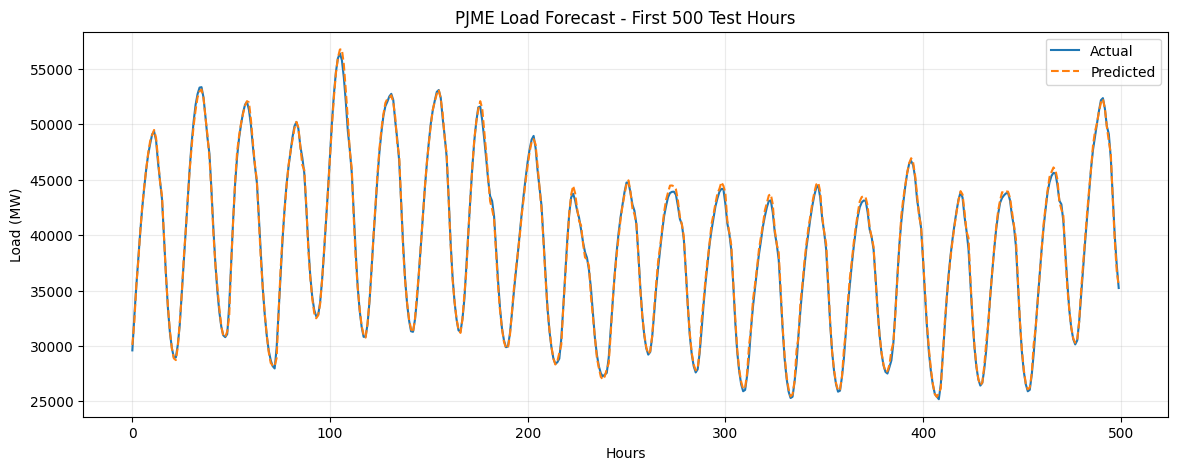

In [26]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os
import random

# ==========================================
# 1. CONFIGURATION & TOGGLES
# ==========================================
class Config:
    FORCE_CPU = False

    SEQ_LENGTH = 24
    PREDICT_HORIZON = 1
    HIDDEN_SIZE = 128
    NUM_LAYERS = 2
    DROPOUT = 0.3
    BATCH_SIZE = 64
    LEARNING_RATE = 0.001
    EPOCHS = 20

    DATA_FILES = [
        './data/AEP_hourly.csv',
        './data/COMED_hourly.csv',
        './data/DAYTON_hourly.csv',
        './data/DEOK_hourly.csv',
        './data/DOM_hourly.csv',
        './data/DUQ_hourly.csv',
        './data/EKPC_hourly.csv',
        './data/FE_hourly.csv',
        './data/NI_hourly.csv',
        './data/PJME_hourly.csv',
        './data/PJMW_hourly.csv',
        './data/PJM_Load_hourly.csv',
        './data/pjm_hourly_est.csv'
    ]

    TARGET_REGION = 'PJME'

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

def get_device():
    if Config.FORCE_CPU:
        return torch.device("cpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
print("Using device:", DEVICE)

# ==========================================
# 2. DATA PREPROCESSING (MULTI-FILE)
# ==========================================
def load_and_process_data():
    print("Loading and merging multiple region files...")
    main_df = None
    loaded_regions = []

    for file_path in Config.DATA_FILES:
        # Accept absolute or relative paths
        if os.path.isabs(file_path):
            path = file_path
        else:
            # helpful fallback: look in current working dir or kaggle input dir
            path = os.path.join(os.getcwd(), file_path)
            if not os.path.exists(path):
                path = os.path.join('./data', os.path.basename(file_path))

        if not os.path.exists(path):
            print(f"Warning: {path} not found. Skipping.")
            continue

        df = pd.read_csv(path)

        # Robust datetime detection
        dt_col = None
        for candidate in ['Datetime', 'datetime', 'Date', 'date', df.columns[0]]:
            if candidate in df.columns:
                dt_col = candidate
                break
        if dt_col is None:
            raise ValueError(f"No datetime-like column found in {path}")

        df = df.rename(columns={dt_col: 'Datetime'})
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df = df.set_index('Datetime')
        df = df.sort_index()
        df = df[~df.index.duplicated(keep='first')]

        # Robust target column detection (find numeric column, prefer 'MW')
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if not numeric_cols:
            print(f"Warning: no numeric columns found in {path}. Skipping.")
            continue
        col_name = next((c for c in numeric_cols if 'MW' in c or 'mw' in c), numeric_cols[0])

        # region name from filename (basename, not whole path)
        region_name = os.path.basename(path).split('_')[0].upper()
        df = df.rename(columns={col_name: region_name})

        # Keep only the renamed column (plus optionally other numeric columns if wanted)
        df = df[[region_name]]

        # Merge: use outer join to preserve timestamps, we'll interpolate later
        if main_df is None:
            main_df = df
        else:
            main_df = main_df.merge(df, left_index=True, right_index=True, how='outer')

        loaded_regions.append(region_name)

    if main_df is None or main_df.empty:
        raise ValueError("No data loaded. Check file paths and dataset availability.")

    # Time features
    main_df = main_df.sort_index()
    main_df['hour'] = main_df.index.hour
    main_df['day_of_week'] = main_df.index.dayofweek
    main_df['month'] = main_df.index.month
    main_df['day_of_year'] = main_df.index.dayofyear

    # Interpolate and fill remaining NaNs
    main_df = main_df.interpolate(method='time', limit_direction='both')
    main_df = main_df.fillna(method='ffill').fillna(method='bfill')

    # Move target region to column 0
    cols = list(main_df.columns)
    target = Config.TARGET_REGION.upper()
    if target in cols:
        cols.insert(0, cols.pop(cols.index(target)))
        main_df = main_df[cols]
    else:
        raise ValueError(f"Target region {target} not found. Loaded regions: {loaded_regions}")

    print(f"Merged Data Shape: {main_df.shape}")
    print(f"Features: {list(main_df.columns)}")
    print(f"Time Range: {main_df.index.min()} to {main_df.index.max()}")
    return main_df

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def create_sequences(data_values, seq_length):
    sequences = []
    labels = []
    target_idx = 0
    for i in range(len(data_values) - seq_length):
        seq = data_values[i : i + seq_length]
        label = data_values[i + seq_length, target_idx]
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)

# ==========================================
# 3. MODEL DEFINITION
# ==========================================
class MultiRegionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1, dropout=0.2):
        super(MultiRegionLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        effective_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=effective_dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # allocate h0 and c0 on same device as x (works for cpu/cuda/mps)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# ==========================================
# 4. TRAINING & EVALUATION
# ==========================================
def train_model():
    df = load_and_process_data()

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df.values)

    X, y = create_sequences(scaled_data, Config.SEQ_LENGTH)
    print(f"Created sequences. X shape: {X.shape}, y shape: {y.shape}")

    split_idx = int(len(X) * 0.90)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train),
                              batch_size=Config.BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(TimeSeriesDataset(X_test, y_test),
                             batch_size=Config.BATCH_SIZE, shuffle=False)

    input_size = X.shape[2]
    model = MultiRegionLSTM(input_size, Config.HIDDEN_SIZE, Config.NUM_LAYERS, dropout=Config.DROPOUT).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)

    print(f"Model input features: {input_size}")

    train_losses = []
    for epoch in range(Config.EPOCHS):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches if n_batches > 0 else 0.0
        train_losses.append(avg_loss)
        train_rmse = np.sqrt(avg_loss)
        print(f"Epoch [{epoch+1}/{Config.EPOCHS}] Avg Loss: {avg_loss:.6f} | Train RMSE: {train_rmse:.4f}")

    # Evaluation
    model.eval()
    preds_list, acts_list = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(DEVICE)
            out = model(batch_X).cpu().numpy().reshape(-1)
            preds_list.append(out)
            acts_list.append(batch_y.numpy().reshape(-1))

    preds = np.concatenate(preds_list)
    acts = np.concatenate(acts_list)

    # Inverse transform
    n = len(preds)
    n_features = scaled_data.shape[1]
    dummy_pred = np.zeros((n, n_features))
    dummy_act = np.zeros((n, n_features))
    dummy_pred[:, 0] = preds
    dummy_act[:, 0] = acts
    inv_pred = scaler.inverse_transform(dummy_pred)[:, 0]
    inv_act = scaler.inverse_transform(dummy_act)[:, 0]

    mae = np.mean(np.abs(inv_pred - inv_act))
    rmse = np.sqrt(np.mean((inv_pred - inv_act) ** 2))
    # safe MAPE
    nonzero = inv_act != 0
    mape = np.mean(np.abs((inv_act[nonzero] - inv_pred[nonzero]) / inv_act[nonzero])) * 100 if nonzero.sum() > 0 else np.nan

    print("\nFINAL RESULTS")
    print(f"RMSE: {rmse:.2f} MW")
    print(f"MAE : {mae:.2f} MW")
    print(f"MAPE: {mape if not np.isnan(mape) else 'N/A'}%")

    # Plot first N points
    limit = min(500, len(inv_act))
    plt.figure(figsize=(14,5))
    plt.plot(inv_act[:limit], label='Actual')
    plt.plot(inv_pred[:limit], label='Predicted', linestyle='--')
    plt.title(f"{Config.TARGET_REGION} Load Forecast - First {limit} Test Hours")
    plt.xlabel("Hours")
    plt.ylabel("Load (MW)")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    return model, scaler, train_losses

if __name__ == "__main__":
    train_model()


# Linear Regression

Using device: cuda


/tmp/ipykernel_5268/2457059717.py:107: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  main_df = main_df.fillna(method='ffill').fillna(method='bfill')


Epoch 1 | Loss: 0.003506 | RMSE: 0.0592
Epoch 2 | Loss: 0.001020 | RMSE: 0.0319
Epoch 3 | Loss: 0.000955 | RMSE: 0.0309
Epoch 4 | Loss: 0.000671 | RMSE: 0.0259
Epoch 5 | Loss: 0.000635 | RMSE: 0.0252
Epoch 6 | Loss: 0.000578 | RMSE: 0.0240
Epoch 7 | Loss: 0.000500 | RMSE: 0.0224
Epoch 8 | Loss: 0.000501 | RMSE: 0.0224
Epoch 9 | Loss: 0.000414 | RMSE: 0.0204
Epoch 10 | Loss: 0.000337 | RMSE: 0.0184
Epoch 11 | Loss: 0.000382 | RMSE: 0.0195
Epoch 12 | Loss: 0.000340 | RMSE: 0.0185
Epoch 13 | Loss: 0.000366 | RMSE: 0.0191
Epoch 14 | Loss: 0.000352 | RMSE: 0.0188
Epoch 15 | Loss: 0.000406 | RMSE: 0.0202
Epoch 16 | Loss: 0.000310 | RMSE: 0.0176
Epoch 17 | Loss: 0.000413 | RMSE: 0.0203
Epoch 18 | Loss: 0.000298 | RMSE: 0.0173
Epoch 19 | Loss: 0.000349 | RMSE: 0.0187
Epoch 20 | Loss: 0.000308 | RMSE: 0.0175

FINAL RESULTS
RMSE: 858.58 MW
MAE : 728.90 MW
MAPE: 2.49%


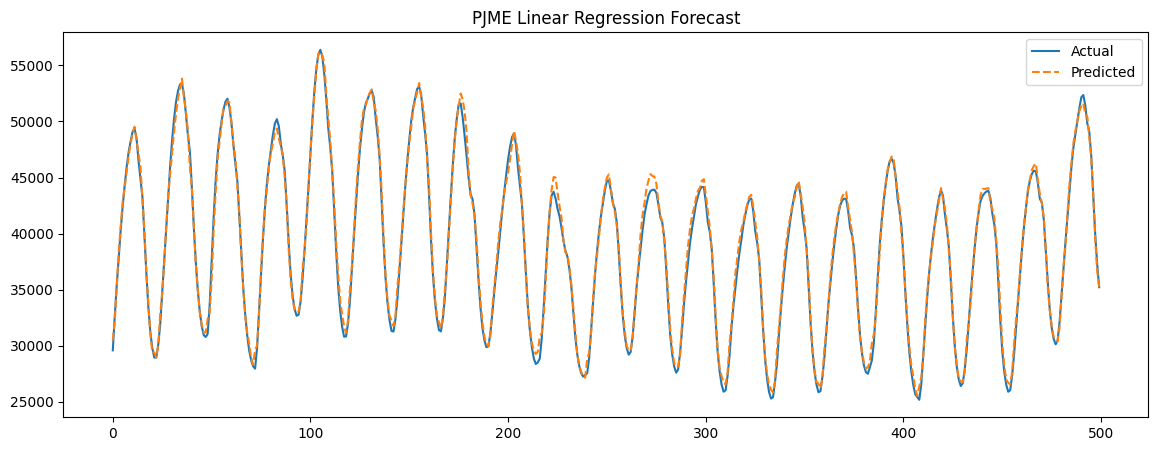

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os
import random

# ==========================================
# 1. CONFIGURATION
# ==========================================
class Config:
    FORCE_CPU = False

    SEQ_LENGTH = 24
    PREDICT_HORIZON = 1
    BATCH_SIZE = 64
    LEARNING_RATE = 0.001
    EPOCHS = 20

    DATA_FILES = [
        './data/AEP_hourly.csv',
        './data/COMED_hourly.csv',
        './data/DAYTON_hourly.csv',
        './data/DEOK_hourly.csv',
        './data/DOM_hourly.csv',
        './data/DUQ_hourly.csv',
        './data/EKPC_hourly.csv',
        './data/FE_hourly.csv',
        './data/NI_hourly.csv',
        './data/PJME_hourly.csv',
        './data/PJMW_hourly.csv',
        './data/PJM_Load_hourly.csv',
        './data/pjm_hourly_est.csv'
    ]

    TARGET_REGION = 'PJME'


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()


def get_device():
    if Config.FORCE_CPU:
        return torch.device("cpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()
print("Using device:", DEVICE)

# ==========================================
# 2. DATA PREPROCESSING（完全保留原逻辑）
# ==========================================
def load_and_process_data():
    main_df = None
    loaded_regions = []

    for file_path in Config.DATA_FILES:
        if not os.path.exists(file_path):
            continue

        df = pd.read_csv(file_path)

        df.rename(columns={df.columns[0]: 'Datetime'}, inplace=True)
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df.set_index('Datetime', inplace=True)
        df = df.sort_index()
        df = df[~df.index.duplicated(keep='first')]

        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if not numeric_cols:
            continue

        col_name = numeric_cols[0]
        region = os.path.basename(file_path).split('_')[0].upper()
        df = df.rename(columns={col_name: region})
        df = df[[region]]

        if main_df is None:
            main_df = df
        else:
            main_df = main_df.merge(df, left_index=True, right_index=True, how='outer')

        loaded_regions.append(region)

    if main_df is None:
        raise ValueError("No data loaded")

    # 时间特征
    main_df = main_df.sort_index()
    main_df['hour'] = main_df.index.hour
    main_df['day_of_week'] = main_df.index.dayofweek
    main_df['month'] = main_df.index.month
    main_df['day_of_year'] = main_df.index.dayofyear

    # ⭐关键：完全保留原插值逻辑
    main_df = main_df.interpolate(method='time', limit_direction='both')
    main_df = main_df.fillna(method='ffill').fillna(method='bfill')

    # target 放第一列
    cols = list(main_df.columns)
    target = Config.TARGET_REGION
    cols.insert(0, cols.pop(cols.index(target)))
    main_df = main_df[cols]

    return main_df


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self): return len(self.X)

    def __getitem__(self, idx): return self.X[idx], self.y[idx]


def create_sequences(data_values, seq_length):
    X, y = [], []
    for i in range(len(data_values) - seq_length):
        X.append(data_values[i:i+seq_length])
        y.append(data_values[i+seq_length, 0])
    return np.array(X), np.array(y)


# ==========================================
# 3. LINEAR REGRESSION（唯一改动）
# ==========================================
class LinearRegressionModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.linear = nn.Linear(input_size, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        return self.linear(x)


# ==========================================
# 4. TRAINING & EVAL（保持一致）
# ==========================================
def train_model():
    df = load_and_process_data()

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df.values)

    X, y = create_sequences(scaled_data, Config.SEQ_LENGTH)

    split = int(len(X) * 0.9)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train),
                              batch_size=Config.BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(TimeSeriesDataset(X_test, y_test),
                             batch_size=Config.BATCH_SIZE, shuffle=False)

    input_size = X.shape[1] * X.shape[2]
    model = LinearRegressionModel(input_size).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)

    # ===== TRAIN =====
    for epoch in range(Config.EPOCHS):
        model.train()
        total_loss = 0

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            out = model(Xb).squeeze()
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.6f} | RMSE: {np.sqrt(avg_loss):.4f}")

    # ===== EVAL =====
    model.eval()
    preds, acts = [], []

    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(DEVICE)
            out = model(Xb).cpu().numpy().flatten()
            preds.append(out)
            acts.append(yb.numpy())

    preds = np.concatenate(preds)
    acts = np.concatenate(acts)

    # inverse scaling（完全一致）
    n = len(preds)
    n_features = scaled_data.shape[1]

    dummy_pred = np.zeros((n, n_features))
    dummy_act = np.zeros((n, n_features))

    dummy_pred[:, 0] = preds
    dummy_act[:, 0] = acts

    inv_pred = scaler.inverse_transform(dummy_pred)[:, 0]
    inv_act = scaler.inverse_transform(dummy_act)[:, 0]

    # ===== SAME METRICS =====
    mae = np.mean(np.abs(inv_pred - inv_act))
    rmse = np.sqrt(np.mean((inv_pred - inv_act) ** 2))

    nonzero = inv_act != 0
    mape = np.mean(np.abs((inv_act[nonzero] - inv_pred[nonzero]) / inv_act[nonzero])) * 100

    print("\nFINAL RESULTS")
    print(f"RMSE: {rmse:.2f} MW")
    print(f"MAE : {mae:.2f} MW")
    print(f"MAPE: {mape:.2f}%")

    # ===== PLOT =====
    plt.figure(figsize=(14,5))
    plt.plot(inv_act[:500], label='Actual')
    plt.plot(inv_pred[:500], '--', label='Predicted')
    plt.legend()
    plt.title(f"{Config.TARGET_REGION} Linear Regression Forecast")
    plt.show()


if __name__ == "__main__":
    train_model()

# XGBoost

/tmp/ipykernel_5268/3994803492.py:81: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  main_df = main_df.fillna(method='ffill').fillna(method='bfill')


Training XGBoost...

FINAL RESULTS (XGBoost)
RMSE: 435.47 MW
MAE : 330.50 MW
MAPE: 1.05%


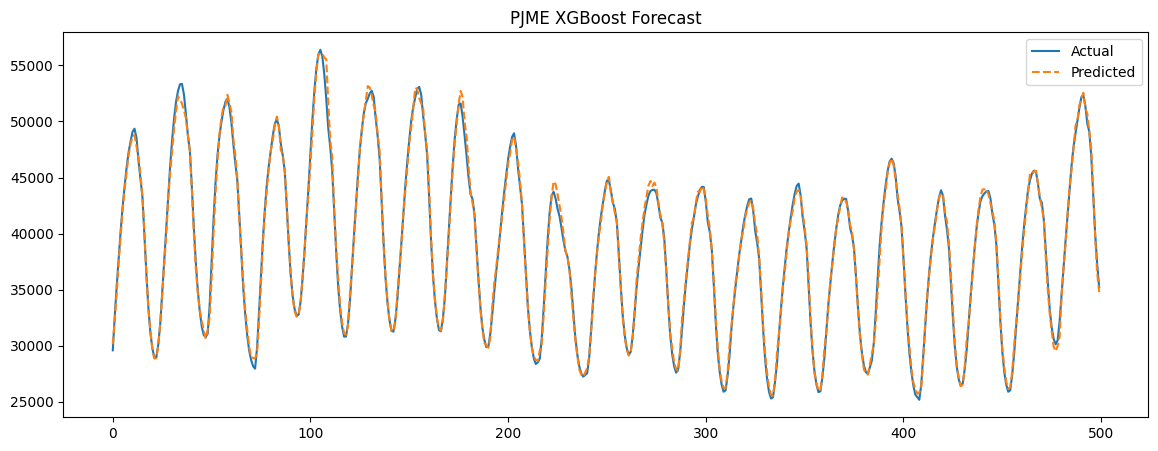

In [16]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os
import random
import xgboost as xgb

# ==========================================
# 1. CONFIGURATION（完全保留）
# ==========================================
class Config:
    SEQ_LENGTH = 24
    DATA_FILES = [
        './data/AEP_hourly.csv',
        './data/COMED_hourly.csv',
        './data/DAYTON_hourly.csv',
        './data/DEOK_hourly.csv',
        './data/DOM_hourly.csv',
        './data/DUQ_hourly.csv',
        './data/EKPC_hourly.csv',
        './data/FE_hourly.csv',
        './data/NI_hourly.csv',
        './data/PJME_hourly.csv',
        './data/PJMW_hourly.csv',
        './data/PJM_Load_hourly.csv',
        './data/pjm_hourly_est.csv'
    ]
    TARGET_REGION = 'PJME'


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed()

# ==========================================
# 2. DATA PREPROCESSING（完全不改）
# ==========================================
def load_and_process_data():
    main_df = None

    for file_path in Config.DATA_FILES:
        if not os.path.exists(file_path):
            continue

        df = pd.read_csv(file_path)

        df.rename(columns={df.columns[0]: 'Datetime'}, inplace=True)
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df.set_index('Datetime', inplace=True)
        df = df.sort_index()
        df = df[~df.index.duplicated(keep='first')]

        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if not numeric_cols:
            continue

        col_name = numeric_cols[0]
        region = os.path.basename(file_path).split('_')[0].upper()
        df = df.rename(columns={col_name: region})
        df = df[[region]]

        if main_df is None:
            main_df = df
        else:
            main_df = main_df.merge(df, left_index=True, right_index=True, how='outer')

    main_df = main_df.sort_index()

    # 时间特征
    main_df['hour'] = main_df.index.hour
    main_df['day_of_week'] = main_df.index.dayofweek
    main_df['month'] = main_df.index.month
    main_df['day_of_year'] = main_df.index.dayofyear

    # ⭐必须保持一致
    main_df = main_df.interpolate(method='time', limit_direction='both')
    main_df = main_df.fillna(method='ffill').fillna(method='bfill')

    # target 放第一列
    cols = list(main_df.columns)
    target = Config.TARGET_REGION
    cols.insert(0, cols.pop(cols.index(target)))
    main_df = main_df[cols]

    return main_df


def create_sequences(data_values, seq_length):
    X, y = [], []
    for i in range(len(data_values) - seq_length):
        X.append(data_values[i:i+seq_length])
        y.append(data_values[i+seq_length, 0])
    return np.array(X), np.array(y)


# ==========================================
# 3. TRAIN + EVAL（XGBoost）
# ==========================================
def train_model():
    df = load_and_process_data()

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df.values)

    X, y = create_sequences(scaled_data, Config.SEQ_LENGTH)

    # ⭐ flatten（关键）
    X = X.reshape(X.shape[0], -1)

    split = int(len(X) * 0.9)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # ==========================================
    # XGBoost MODEL
    # ==========================================
    model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )

    print("Training XGBoost...")
    model.fit(X_train, y_train)

    # ==========================================
    # EVALUATION（完全一致）
    # ==========================================
    preds = model.predict(X_test)
    acts = y_test

    n = len(preds)
    n_features = scaled_data.shape[1]

    dummy_pred = np.zeros((n, n_features))
    dummy_act = np.zeros((n, n_features))

    dummy_pred[:, 0] = preds
    dummy_act[:, 0] = acts

    inv_pred = scaler.inverse_transform(dummy_pred)[:, 0]
    inv_act = scaler.inverse_transform(dummy_act)[:, 0]

    mae = np.mean(np.abs(inv_pred - inv_act))
    rmse = np.sqrt(np.mean((inv_pred - inv_act) ** 2))

    nonzero = inv_act != 0
    mape = np.mean(np.abs((inv_act[nonzero] - inv_pred[nonzero]) / inv_act[nonzero])) * 100

    print("\nFINAL RESULTS (XGBoost)")
    print(f"RMSE: {rmse:.2f} MW")
    print(f"MAE : {mae:.2f} MW")
    print(f"MAPE: {mape:.2f}%")

    # ==========================================
    # PLOT
    # ==========================================
    plt.figure(figsize=(14,5))
    plt.plot(inv_act[:500], label='Actual')
    plt.plot(inv_pred[:500], '--', label='Predicted')
    plt.legend()
    plt.title(f"{Config.TARGET_REGION} XGBoost Forecast")
    plt.show()


if __name__ == "__main__":
    train_model()

# GRU

Using device: cuda


/tmp/ipykernel_5268/3415742911.py:103: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  main_df = main_df.fillna(method='ffill').fillna(method='bfill')


Epoch 1 | Loss: 0.001770 | RMSE: 0.0421
Epoch 2 | Loss: 0.000408 | RMSE: 0.0202
Epoch 3 | Loss: 0.000265 | RMSE: 0.0163
Epoch 4 | Loss: 0.000217 | RMSE: 0.0147
Epoch 5 | Loss: 0.000166 | RMSE: 0.0129
Epoch 6 | Loss: 0.000160 | RMSE: 0.0126
Epoch 7 | Loss: 0.000145 | RMSE: 0.0120
Epoch 8 | Loss: 0.000126 | RMSE: 0.0112
Epoch 9 | Loss: 0.000113 | RMSE: 0.0106
Epoch 10 | Loss: 0.000107 | RMSE: 0.0104
Epoch 11 | Loss: 0.000095 | RMSE: 0.0098
Epoch 12 | Loss: 0.000094 | RMSE: 0.0097
Epoch 13 | Loss: 0.000090 | RMSE: 0.0095
Epoch 14 | Loss: 0.000088 | RMSE: 0.0094
Epoch 15 | Loss: 0.000086 | RMSE: 0.0093
Epoch 16 | Loss: 0.000079 | RMSE: 0.0089
Epoch 17 | Loss: 0.000076 | RMSE: 0.0087
Epoch 18 | Loss: 0.000073 | RMSE: 0.0085
Epoch 19 | Loss: 0.000069 | RMSE: 0.0083
Epoch 20 | Loss: 0.000063 | RMSE: 0.0079

FINAL RESULTS (GRU)
RMSE: 361.62 MW
MAE : 277.93 MW
MAPE: 0.93%


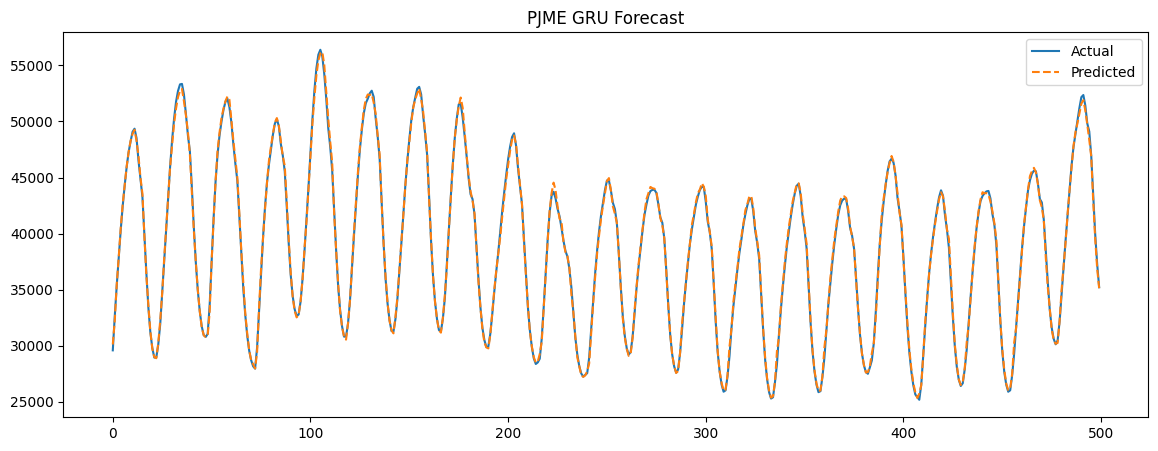

In [13]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os
import random

# ==========================================
# 1. CONFIGURATION
# ==========================================
class Config:
    FORCE_CPU = False

    SEQ_LENGTH = 24
    HIDDEN_SIZE = 128
    NUM_LAYERS = 2
    DROPOUT = 0.2
    BATCH_SIZE = 64
    LEARNING_RATE = 0.001
    EPOCHS = 20

    DATA_FILES = [
        './data/AEP_hourly.csv',
        './data/COMED_hourly.csv',
        './data/DAYTON_hourly.csv',
        './data/DEOK_hourly.csv',
        './data/DOM_hourly.csv',
        './data/DUQ_hourly.csv',
        './data/EKPC_hourly.csv',
        './data/FE_hourly.csv',
        './data/NI_hourly.csv',
        './data/PJME_hourly.csv',
        './data/PJMW_hourly.csv',
        './data/PJM_Load_hourly.csv',
        './data/pjm_hourly_est.csv'
    ]

    TARGET_REGION = 'PJME'


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()


def get_device():
    if Config.FORCE_CPU:
        return torch.device("cpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()
print("Using device:", DEVICE)

# ==========================================
# 2. DATA PREPROCESSING（完全不变）
# ==========================================
def load_and_process_data():
    main_df = None

    for file_path in Config.DATA_FILES:
        if not os.path.exists(file_path):
            continue

        df = pd.read_csv(file_path)

        df.rename(columns={df.columns[0]: 'Datetime'}, inplace=True)
        df['Datetime'] = pd.to_datetime(df['Datetime'])
        df.set_index('Datetime', inplace=True)
        df = df.sort_index()
        df = df[~df.index.duplicated(keep='first')]

        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if not numeric_cols:
            continue

        col_name = numeric_cols[0]
        region = os.path.basename(file_path).split('_')[0].upper()
        df = df.rename(columns={col_name: region})
        df = df[[region]]

        if main_df is None:
            main_df = df
        else:
            main_df = main_df.merge(df, left_index=True, right_index=True, how='outer')

    main_df = main_df.sort_index()

    # 时间特征
    main_df['hour'] = main_df.index.hour
    main_df['day_of_week'] = main_df.index.dayofweek
    main_df['month'] = main_df.index.month
    main_df['day_of_year'] = main_df.index.dayofyear

    main_df = main_df.interpolate(method='time', limit_direction='both')
    main_df = main_df.fillna(method='ffill').fillna(method='bfill')

    # target 放第一列
    cols = list(main_df.columns)
    target = Config.TARGET_REGION
    cols.insert(0, cols.pop(cols.index(target)))
    main_df = main_df[cols]

    return main_df


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self): return len(self.X)

    def __getitem__(self, idx): return self.X[idx], self.y[idx]


def create_sequences(data_values, seq_length):
    X, y = [], []
    for i in range(len(data_values) - seq_length):
        X.append(data_values[i:i+seq_length])
        y.append(data_values[i+seq_length, 0])
    return np.array(X), np.array(y)


# ==========================================
# 3. GRU MODEL（唯一改动）
# ==========================================
class MultiRegionGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out


# ==========================================
# 4. TRAIN & EVAL（完全一致）
# ==========================================
def train_model():
    df = load_and_process_data()

    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df.values)

    X, y = create_sequences(scaled_data, Config.SEQ_LENGTH)

    split = int(len(X) * 0.9)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train),
                              batch_size=Config.BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(TimeSeriesDataset(X_test, y_test),
                             batch_size=Config.BATCH_SIZE, shuffle=False)

    input_size = X.shape[2]
    model = MultiRegionGRU(input_size, Config.HIDDEN_SIZE, Config.NUM_LAYERS).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)

    # ===== TRAIN =====
    for epoch in range(Config.EPOCHS):
        model.train()
        total_loss = 0

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            out = model(Xb).squeeze()
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.6f} | RMSE: {np.sqrt(avg_loss):.4f}")

    # ===== EVAL =====
    model.eval()
    preds, acts = [], []

    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(DEVICE)
            out = model(Xb).cpu().numpy().flatten()
            preds.append(out)
            acts.append(yb.numpy())

    preds = np.concatenate(preds)
    acts = np.concatenate(acts)

    # inverse scaling
    n = len(preds)
    n_features = scaled_data.shape[1]

    dummy_pred = np.zeros((n, n_features))
    dummy_act = np.zeros((n, n_features))

    dummy_pred[:, 0] = preds
    dummy_act[:, 0] = acts

    inv_pred = scaler.inverse_transform(dummy_pred)[:, 0]
    inv_act = scaler.inverse_transform(dummy_act)[:, 0]

    mae = np.mean(np.abs(inv_pred - inv_act))
    rmse = np.sqrt(np.mean((inv_pred - inv_act) ** 2))

    nonzero = inv_act != 0
    mape = np.mean(np.abs((inv_act[nonzero] - inv_pred[nonzero]) / inv_act[nonzero])) * 100

    print("\nFINAL RESULTS (GRU)")
    print(f"RMSE: {rmse:.2f} MW")
    print(f"MAE : {mae:.2f} MW")
    print(f"MAPE: {mape:.2f}%")

    plt.figure(figsize=(14,5))
    plt.plot(inv_act[:500], label='Actual')
    plt.plot(inv_pred[:500], '--', label='Predicted')
    plt.legend()
    plt.title(f"{Config.TARGET_REGION} GRU Forecast")
    plt.show()


if __name__ == "__main__":
    train_model()